# FANCI Random Forest — tái lập Classification Module trên bộ genAI

Notebook này xây dựng **baseline FANCI độc lập** để so sánh với hệ thống đang nghiên cứu:

- chỉ dùng **Classification Module**; không dùng Intelligence Module, whitelist hay truy vấn ngoài;
- đầu vào là `train_genAI.csv`, `val_genAI.csv`, `test_genAI.csv`;
- bộ trích xuất đặc trưng bám theo mã nguồn FANCI chính thức tại commit
  [`d6c7d08`](https://github.com/fanci-dga-detection/fanci/tree/d6c7d0885f95a6ef1a6e0efce66e50e22b47e0a2);
- classifier là Random Forest cấu hình `mix` của tác giả:
  `criterion='gini'`, `max_features=18`, `n_estimators=785`;
- validation chỉ dùng để chọn threshold triển khai; test chỉ đánh giá một lần sau khi khóa model và threshold.

## Quyết định tái lập 44/45 chiều

Bài báo mô tả 21 nhóm đặc trưng và phần phụ lục gọi vector là 44 chiều. Tuy nhiên, code chính thức mã hóa
số phần domain thành **4 phần tử one-hot**, sinh **21 thống kê n-gram**, và bộ kiểm thử chính thức truy cập
các chỉ số `0..44`. Vì vậy code thực thi của tác giả tạo **45 chiều**. Notebook chọn vector 45 chiều để
tương thích với implementation có thể kiểm chứng của tác giả. Cell kiểm thử phía dưới khóa thứ tự và kích
thước này; đây không phải một đặc trưng mới do notebook tự thêm.

Với domain hợp lệ, công thức được giữ theo code chính thức. Notebook chỉ thêm kiểm tra đầu vào, cache,
progress bar, báo cáo metric và xuất artifact; các trường hợp lỗi số học hiếm gặp được trả về 0 theo chủ
đích fallback của code gốc.


In [1]:
# Các phiên bản này chạy được trên cả Colab Python 3.11 và 3.13.
# Nếu Colab yêu cầu sau khi cài lần đầu: Runtime > Restart session.
%pip install -q "numpy==2.2.3" "pandas==2.2.3" "scikit-learn==1.6.1" "joblib==1.4.2" "tqdm==4.67.1" "matplotlib==3.10.0" "seaborn==0.13.2" "psutil==6.1.1" "jinja2==3.1.6"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.5/287.5 kB 19.3 MB/s eta 0:00:00


In [1]:
import hashlib
import json
import math
import os
import platform
import re
import sys
import time
import urllib.request
import warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
import sklearn
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tqdm.auto import tqdm

SEED = 2026
np.random.seed(SEED)
print("Python:", platform.python_version())
print("NumPy:", np.__version__, "| pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__, "| joblib:", joblib.__version__)


Python: 3.13.15
NumPy: 2.2.3 | pandas: 2.2.3
scikit-learn: 1.6.1 | joblib: 1.4.2


## Cấu trúc thư mục trên Google Drive

Đặt ba file dữ liệu như sau:

```text
MyDrive/
└── FANCI_RF_genAI/
    ├── data/
    │   ├── train_genAI.csv
    │   ├── val_genAI.csv
    │   └── test_genAI.csv
    ├── artifact/       # notebook tự tạo
    ├── cache/          # notebook tự tạo, giúp chạy lại nhanh
    └── reports/        # notebook tự tạo
```

CSV cần có cột `domain_name` (hoặc `domain`) và `label`; cột `subclass` được giữ để báo cáo theo họ DGA.


In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DEFAULT_ROOT = Path("/content/drive/MyDrive/FANCI_RF_genAI")
except ImportError:
    DEFAULT_ROOT = Path.cwd() / "FANCI_RF_genAI"

ROOT = DEFAULT_ROOT
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifact"
CACHE_DIR = ROOT / "cache"
REPORT_DIR = ROOT / "reports"
for directory in (ARTIFACT_DIR, CACHE_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_genAI.csv"
VAL_PATH = DATA_DIR / "val_genAI.csv"
TEST_PATH = DATA_DIR / "test_genAI.csv"

# Chỉ ảnh hưởng tốc độ/RAM, không đổi model.
FEATURE_JOBS = min(2, max(1, os.cpu_count() or 1))
RF_N_JOBS = -1
TREE_CHUNK = 25

# Áp dụng cùng chính sách này cho mọi baseline nếu muốn so sánh trực tiếp.
REMOVE_CONFLICTING_DOMAINS = True
REMOVE_WITHIN_SPLIT_DUPLICATES = True
REMOVE_CROSS_SPLIT_OVERLAP = True

SOURCE_COMMIT = "d6c7d0885f95a6ef1a6e0efce66e50e22b47e0a2"
EXTRACTOR_VERSION = "official-fanci-d6c7d08-45d-v1"
PSL_URL = (
    "https://raw.githubusercontent.com/fanci-dga-detection/fanci/"
    f"{SOURCE_COMMIT}/bin/public_suffix.txt"
)
PSL_SHA256 = "ce5c21dd349eb4d93635566d8fd15287ce31e9dc887df3c594a0aef0f4d2ade0"
PSL_PATH = ARTIFACT_DIR / "fanci_public_suffix_d6c7d08.txt"
BUNDLE_PATH = ARTIFACT_DIR / "fanci_rf_official45_bundle.joblib"

print("ROOT:", ROOT)
print("Feature workers:", FEATURE_JOBS, "| RF workers:", RF_N_JOBS)
for path in (TRAIN_PATH, VAL_PATH, TEST_PATH):
    print(path, "->", "OK" if path.is_file() else "MISSING")


Mounted at /content/drive
ROOT: /content/drive/MyDrive/FANCI_RF_genAI
Feature workers: 2 | RF workers: -1
/content/drive/MyDrive/FANCI_RF_genAI/data/train_genAI.csv -> OK
/content/drive/MyDrive/FANCI_RF_genAI/data/val_genAI.csv -> OK
/content/drive/MyDrive/FANCI_RF_genAI/data/test_genAI.csv -> OK


In [3]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def download_atomic(url: str, destination: Path) -> None:
    temporary = destination.with_suffix(destination.suffix + ".part")
    if temporary.exists():
        temporary.unlink()
    urllib.request.urlretrieve(url, temporary)
    temporary.replace(destination)


if not PSL_PATH.is_file() or sha256_file(PSL_PATH) != PSL_SHA256:
    print("Đang tải snapshot Public Suffix List từ commit FANCI đã khóa...")
    download_atomic(PSL_URL, PSL_PATH)

actual_psl_hash = sha256_file(PSL_PATH)
if actual_psl_hash != PSL_SHA256:
    raise RuntimeError(
        f"PSL hash không khớp: expected={PSL_SHA256}, actual={actual_psl_hash}"
    )
print("PSL:", PSL_PATH, "| SHA256:", actual_psl_hash)


Đang tải snapshot Public Suffix List từ commit FANCI đã khóa...
PSL: /content/drive/MyDrive/FANCI_RF_genAI/artifact/fanci_public_suffix_d6c7d08.txt | SHA256: ce5c21dd349eb4d93635566d8fd15287ce31e9dc887df3c594a0aef0f4d2ade0


## Bộ trích xuất đặc trưng tương thích source chính thức

Thứ tự 45 chiều được khóa trong `FEATURE_NAMES`. Một số hành vi tưởng như lạ được giữ vì đó là hành vi
thật của code tác giả: `parts` là one-hot 4 chiều; IPv4 dùng regex; `contains_www_dot` tìm chuỗi `www.`;
thống kê n-gram là `[std, median, mean, min, max, q25, q75]` cho n bằng 1, 2 và 3.


In [4]:
HEX_DIGITS = set("0123456789abcdef")
VOWELS = set("aeiou")
PARTS_MAX_CONSIDERED = 4
IPV4_PATTERN = re.compile(
    r"(([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.){3}"
    r"([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])"
)

NGRAM_STATS = ("std", "median", "mean", "min", "max", "q25", "q75")
FEATURE_NAMES = [
    "domain_length",
    "parts_1", "parts_2", "parts_3", "parts_4plus",
    "vowel_ratio", "digit_ratio", "contains_ipv4", "contains_digit",
    "has_valid_tld", "contains_one_char_subdomain", "contains_www_dot",
    "mean_suffix_free_part_length", "prefix_repetition", "character_diversity",
    "contains_only_digits_part", "contains_tld_as_infix",
]
for n in (1, 2, 3):
    FEATURE_NAMES.extend([f"ngram{n}_{name}" for name in NGRAM_STATS])
FEATURE_NAMES.extend([
    "hex_part_ratio", "underscore_ratio", "alphabet_size", "shannon_entropy",
    "repeated_char_ratio", "consecutive_consonant_ratio", "consecutive_digit_ratio",
])
assert len(FEATURE_NAMES) == 45


def load_public_suffixes(path: Path):
    # Giữ logic parser của data_processing/data.py trong source FANCI.
    lines = [line.strip().lower() for line in path.read_text(encoding="utf-8").splitlines()]
    entries = ["." + line for line in lines if line and not line.startswith(("/", "*"))]
    valid_tlds = frozenset(item for item in entries if len(item.split(".")) == 2)
    return valid_tlds, frozenset(entries)


VALID_TLDS, VALID_PUBLIC_SUFFIXES = load_public_suffixes(PSL_PATH)
print("Valid TLDs:", len(VALID_TLDS), "| public suffixes:", len(VALID_PUBLIC_SUFFIXES))


class OfficialFANCI45Extractor:
    def __init__(self, valid_tlds, valid_public_suffixes):
        self.valid_tlds = frozenset(valid_tlds)
        self.valid_public_suffixes = frozenset(valid_public_suffixes)

    def _remove_public_suffix(self, parts):
        match = ""
        if len(parts) < 2:
            return tuple(parts), match
        for index in range(len(parts)):
            match = "." + ".".join(parts[index:])
            if match in self.valid_public_suffixes:
                return tuple(parts[:index]), match
        # Giữ hành vi code chính thức: match cuối vẫn được trả về.
        return tuple(parts), match

    @staticmethod
    def _stats(values):
        if not values:
            return [-1.0] * 7
        array = np.asarray(values, dtype=np.float64)
        return [
            float(array.std()), float(np.median(array)), float(array.mean()),
            float(array.min()), float(array.max()),
            float(np.percentile(array, 25)), float(np.percentile(array, 75)),
        ]

    @staticmethod
    def _run_ratio(parts, predicate, denominator):
        if denominator == 0:
            return 0.0
        total = 0
        for part in parts:
            run = 0
            for char in part:
                if predicate(char):
                    run += 1
                else:
                    if run > 1:
                        total += run
                    run = 0
            if run > 1:
                total += run
        return total / denominator

    def extract(self, domain):
        domain = str(domain).strip().lower()
        dot_split = tuple(domain.split("."))
        joined = "".join(dot_split)
        suffix_free_parts, public_suffix = self._remove_public_suffix(dot_split)
        suffix_free = "".join(suffix_free_parts)
        suffix_free_length = len(suffix_free)

        vector = [float(len(domain))]

        part_feature = [0.0] * PARTS_MAX_CONSIDERED
        split_length = len(suffix_free_parts)
        if split_length >= PARTS_MAX_CONSIDERED:
            part_feature[-1] = 1.0
        elif split_length > 0:
            part_feature[split_length - 1] = 1.0
        vector.extend(part_feature)

        alpha_count = sum(char.isalpha() for char in suffix_free)
        vowel_count = sum(char in VOWELS for char in suffix_free)
        digit_count = sum(char.isdigit() for char in suffix_free)
        vector.append(vowel_count / alpha_count if alpha_count else 0.0)
        vector.append(digit_count / suffix_free_length if suffix_free_length else 0.0)
        vector.append(float(bool(IPV4_PATTERN.search(domain))))
        vector.append(float(any(char.isdigit() for char in domain)))
        vector.append(float(bool(public_suffix)))

        one_char_parts = dot_split[:-1] if len(dot_split) > 2 else dot_split
        vector.append(float(any(len(part) == 1 for part in one_char_parts)))
        vector.append(float("www." in domain))
        vector.append(
            sum(map(len, suffix_free_parts)) / len(suffix_free_parts)
            if suffix_free_parts else 0.0
        )
        vector.append(float((domain + domain).find(domain, 1, -1) != -1))

        unigram_counter = Counter(suffix_free)
        vector.append(len(unigram_counter) / suffix_free_length if suffix_free_length else 0.0)

        # Source gốc thực tế kiểm tra "không có chữ cái", không dùng str.isdigit().
        vector.append(float(any(not any(char.isalpha() for char in part) for part in dot_split)))
        # Tương đương source nhưng O(số phần domain), thay vì quét toàn bộ ~1.500 TLD.
        vector.append(float(any(("." + part) in self.valid_tlds for part in suffix_free_parts)))

        ngram_counts = None
        for n in (1, 2, 3):
            counts = Counter(
                suffix_free[index:index + n]
                for index in range(max(0, suffix_free_length - n + 1))
            )
            values = list(counts.values())
            if n == 1:
                ngram_counts = values
            vector.extend(self._stats(values))

        vector.append(
            sum(all(char in HEX_DIGITS for char in part) for part in suffix_free_parts)
            / len(suffix_free_parts)
            if suffix_free_parts else 0.0
        )
        vector.append(suffix_free.count("_") / suffix_free_length if suffix_free_length else 0.0)
        vector.append(float(len(ngram_counts or [])))

        if ngram_counts:
            counts_array = np.asarray(ngram_counts, dtype=np.float64)
            probabilities = counts_array / counts_array.sum()
            entropy = float(-(probabilities * np.log2(probabilities)).sum())
            repeated = float(np.sum(counts_array > 1) / len(counts_array))
        else:
            entropy = 0.0
            repeated = 0.0
        vector.extend([entropy, repeated])

        vector.append(self._run_ratio(
            suffix_free_parts,
            lambda char: char.isalpha() and char not in VOWELS,
            suffix_free_length,
        ))
        vector.append(self._run_ratio(
            suffix_free_parts, lambda char: char.isdigit(), suffix_free_length
        ))

        result = np.asarray(vector, dtype=np.float32)
        if result.shape != (45,) or not np.isfinite(result).all():
            raise ValueError(f"Feature vector lỗi cho domain={domain!r}: shape={result.shape}")
        return result


EXTRACTOR = OfficialFANCI45Extractor(VALID_TLDS, VALID_PUBLIC_SUFFIXES)


Valid TLDs: 1534 | public suffixes: 8098


In [5]:
# Đối chiếu toàn bộ index/công thức trong test/test_extract_features.py của tác giả.
def assert_close(actual, expected, atol=1e-6):
    np.testing.assert_allclose(actual, expected, rtol=0, atol=atol)


official_examples = {
    "rwth": "itsec.rwth-aachen.de",
    "digits": "123huhu384gj8nge8.co.uk",
    "subdomains": "1.2.3.4.5.6.7.8.9.123huhu384gj8nge8.co.uk",
    "vowel_one": "eeeeeeeeeeeeeee",
    "vowel_zero": "ggggg123ggghjkl12323.de",
    "mhm": "m.hm",
    "one_digit": "1",
    "one_letter": "a",
    "only_tld": "de",
    "double_tld": "de.de",
    "triple_tld": "de.de.de",
    "ip_addr": "hu.10.13.37.19.rwth-aachen.de",
    "wwwdot": "wegonweg.www.egioegn.de",
    "wwwtrailingdot": "www.egioegn.de",
    "prefix_repeat": "rwth-aachen.derwth-aachen.de",
    "ngrameasy": "abcdef.de",
    "underscores": "_tcp.ab_cdef1.de",
}
feature = {name: EXTRACTOR.extract(domain) for name, domain in official_examples.items()}
assert all(vector.shape == (45,) for vector in feature.values())

expectations = [
    (feature["rwth"][0], len(official_examples["rwth"])),
    (feature["digits"][0], len(official_examples["digits"])),
    (feature["rwth"][1:5], [0, 1, 0, 0]),
    (feature["digits"][1:5], [1, 0, 0, 0]),
    (feature["subdomains"][1:5], [0, 0, 0, 1]),
    (feature["rwth"][5], 5 / 15),
    (feature["digits"][5], 3 / 9),
    (feature["subdomains"][5], 3 / 9),
    (feature["vowel_one"][5], 1),
    (feature["vowel_zero"][5], 0),
    (feature["digits"][6], 8 / 17),
    (feature["rwth"][7], 0),
    (feature["one_letter"][7], 0),
    (feature["ip_addr"][7], 1),
    (feature["one_digit"][7], 0),
    (feature["mhm"][7], 0),
    (feature["ip_addr"][8], 1),
    (feature["one_digit"][8], 1),
    (feature["one_letter"][8], 0),
    (feature["rwth"][8], 0),
    (feature["rwth"][9], 1),
    (feature["one_digit"][9], 0),
    (feature["only_tld"][9], 0),
    (feature["vowel_zero"][9], 1),
    (feature["vowel_one"][9], 0),
    (feature["rwth"][10], 0),
    (feature["one_letter"][10], 1),
    (feature["one_digit"][10], 1),
    (feature["vowel_zero"][10], 0),
    (feature["vowel_one"][10], 0),
    (feature["subdomains"][10], 1),
    (feature["subdomains"][11], 0),
    (feature["wwwdot"][11], 1),
    (feature["wwwtrailingdot"][11], 1),
    (feature["rwth"][11], 0),
    (feature["rwth"][12], 8),
    (feature["subdomains"][12], 26 / 10),
    (feature["rwth"][13], 0),
    (feature["subdomains"][13], 0),
    (feature["double_tld"][13], 0),
    (feature["prefix_repeat"][13], 1),
    (feature["one_letter"][14], 1),
    (feature["one_digit"][14], 1),
    (feature["rwth"][14], 11 / 16),
    (feature["triple_tld"][14], 1 / 2),
    (feature["rwth"][15], 0),
    (feature["subdomains"][15], 1),
    (feature["one_digit"][15], 1),
    (feature["double_tld"][15], 0),
    (feature["ip_addr"][15], 1),
    (feature["prefix_repeat"][15], 0),
    (feature["rwth"][16], 0),
    (feature["subdomains"][16], 0),
    (feature["one_digit"][16], 0),
    (feature["triple_tld"][16], 1),
    (feature["prefix_repeat"][16], 0),
    (feature["ngrameasy"][38], 1),
    (feature["subdomains"][38], 9 / 10),
    (feature["rwth"][38], 0),
    (feature["rwth"][39], 0),
    (feature["subdomains"][39], 0),
    (feature["prefix_repeat"][39], 0),
    (feature["underscores"][39], 2 / 12),
    (feature["rwth"][40], 11),
    (feature["vowel_one"][40], 1),
    (feature["ngrameasy"][40], 6),
    (feature["one_digit"][40], 1),
    (feature["one_letter"][40], 1),
    (feature["vowel_one"][42], 1),
    (feature["one_letter"][42], 0),
    (feature["one_digit"][42], 0),
    (feature["rwth"][42], 5 / 11),
    (feature["one_digit"][43], 0),
    (feature["vowel_one"][43], 0),
    (feature["rwth"][43], 8 / 16),
    (feature["underscores"][43], 5 / 12),
    (feature["one_digit"][44], 0),
    (feature["vowel_one"][44], 0),
    (feature["rwth"][44], 0),
    (feature["underscores"][44], 0),
    (feature["digits"][44], 6 / 17),
]
for actual, expected in expectations:
    assert_close(actual, expected)

for name in ("mhm", "one_digit", "one_letter"):
    assert_close(feature[name][24:38], [-1] * 14, atol=0)
for start in (17, 24, 31):
    assert_close(feature["ngrameasy"][start:start + 7], [0, 1, 1, 1, 1, 1, 1], atol=0)
assert_close(feature["rwth"][41], 3.375, atol=0.1)
assert_close(feature["vowel_one"][41], 0, atol=0.1)
assert_close(feature["digits"][41], 3.33718, atol=0.05)
print(f"PASS: {len(expectations)} phép đối chiếu và toàn bộ 45 vị trí theo source FANCI.")


PASS: 81 phép đối chiếu và toàn bộ 45 vị trí theo source FANCI.


## Đọc và làm sạch dữ liệu

Domain được `strip`, chuyển chữ thường và bỏ dấu chấm cuối. Domain có nhãn mâu thuẫn trong cùng split bị
loại toàn bộ. Domain trùng được giữ một lần. Nếu bật `REMOVE_CROSS_SPLIT_OVERLAP`, train được ưu tiên,
sau đó validation, rồi test; cách này ngăn cùng một domain xuất hiện ở cả train và test. Báo cáo ghi lại
đầy đủ số mẫu bị loại để thí nghiệm có thể kiểm toán.


In [6]:
def dataframe_fingerprint(frame: pd.DataFrame) -> str:
    columns = ["normalized_domain", "label"]
    hashed = pd.util.hash_pandas_object(frame[columns], index=False).values
    return hashlib.sha256(hashed.tobytes()).hexdigest()


def load_and_clean(path: Path, split_name: str):
    if not path.is_file():
        raise FileNotFoundError(f"Thiếu file: {path}")

    frame = pd.read_csv(path, low_memory=False)
    domain_column = "domain_name" if "domain_name" in frame.columns else "domain"
    required = {domain_column, "label"}
    if not required.issubset(frame.columns):
        raise ValueError(f"{split_name}: cần các cột {sorted(required)}, có {list(frame.columns)}")

    report = {
        "split": split_name,
        "path": str(path),
        "source_sha256": sha256_file(path),
        "rows_read": int(len(frame)),
    }
    keep = [domain_column, "label"] + (["subclass"] if "subclass" in frame.columns else [])
    frame = frame[keep].copy()
    frame.rename(columns={domain_column: "domain"}, inplace=True)
    if "subclass" not in frame:
        frame["subclass"] = "unknown"

    frame["normalized_domain"] = (
        frame["domain"].astype("string").str.strip().str.lower().str.rstrip(".")
    )
    frame["label"] = pd.to_numeric(frame["label"], errors="coerce")
    valid = (
        frame["normalized_domain"].notna()
        & frame["normalized_domain"].ne("")
        & frame["label"].isin([0, 1])
    )
    report["invalid_rows_removed"] = int((~valid).sum())
    frame = frame.loc[valid].copy()
    frame["label"] = frame["label"].astype(np.int8)
    frame["subclass"] = frame["subclass"].fillna("unknown").astype(str)

    conflict_mask = frame.groupby("normalized_domain")["label"].transform("nunique").gt(1)
    report["conflicting_rows"] = int(conflict_mask.sum())
    report["conflicting_domains"] = int(frame.loc[conflict_mask, "normalized_domain"].nunique())
    if REMOVE_CONFLICTING_DOMAINS:
        frame = frame.loc[~conflict_mask].copy()

    duplicate_mask = frame.duplicated("normalized_domain", keep="first")
    report["duplicate_rows"] = int(duplicate_mask.sum())
    if REMOVE_WITHIN_SPLIT_DUPLICATES:
        frame = frame.loc[~duplicate_mask].copy()

    frame.reset_index(drop=True, inplace=True)
    report["rows_after_within_split_cleaning"] = int(len(frame))
    report["class_counts_after_within_split"] = {
        str(key): int(value) for key, value in frame["label"].value_counts().sort_index().items()
    }
    return frame, report


train_df, train_report = load_and_clean(TRAIN_PATH, "train")
val_df, val_report = load_and_clean(VAL_PATH, "validation")
test_df, test_report = load_and_clean(TEST_PATH, "test")

if REMOVE_CROSS_SPLIT_OVERLAP:
    train_domains = set(train_df["normalized_domain"])
    val_overlap = val_df["normalized_domain"].isin(train_domains)
    val_report["cross_split_rows_removed"] = int(val_overlap.sum())
    val_df = val_df.loc[~val_overlap].reset_index(drop=True)

    prior_domains = train_domains | set(val_df["normalized_domain"])
    test_overlap = test_df["normalized_domain"].isin(prior_domains)
    test_report["cross_split_rows_removed"] = int(test_overlap.sum())
    test_df = test_df.loc[~test_overlap].reset_index(drop=True)
else:
    val_report["cross_split_rows_removed"] = 0
    test_report["cross_split_rows_removed"] = 0
train_report["cross_split_rows_removed"] = 0

for frame, report in (
    (train_df, train_report), (val_df, val_report), (test_df, test_report)
):
    report["rows_final"] = int(len(frame))
    report["class_counts_final"] = {
        str(key): int(value)
        for key, value in frame["label"].value_counts().sort_index().items()
    }
    report["fingerprint"] = dataframe_fingerprint(frame)
    if len(frame) == 0 or set(frame["label"].unique()) != {0, 1}:
        raise ValueError(f'{report["split"]}: split rỗng hoặc không đủ hai lớp sau cleaning')
    print(report["split"], "->", report["rows_final"], report["class_counts_final"])

if REMOVE_CROSS_SPLIT_OVERLAP:
    train_domains = set(train_df["normalized_domain"])
    val_domains = set(val_df["normalized_domain"])
    test_domains = set(test_df["normalized_domain"])
    assert train_domains.isdisjoint(val_domains), "Leakage train-validation"
    assert train_domains.isdisjoint(test_domains), "Leakage train-test"
    assert val_domains.isdisjoint(test_domains), "Leakage validation-test"
    print("PASS: ba split không còn domain giao nhau.")

cleaning_report = {
    "settings": {
        "remove_conflicting_domains": REMOVE_CONFLICTING_DOMAINS,
        "remove_within_split_duplicates": REMOVE_WITHIN_SPLIT_DUPLICATES,
        "remove_cross_split_overlap": REMOVE_CROSS_SPLIT_OVERLAP,
    },
    "splits": [train_report, val_report, test_report],
}
(REPORT_DIR / "cleaning_report.json").write_text(
    json.dumps(cleaning_report, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(pd.DataFrame([train_report, val_report, test_report]))


train -> 986314 {'0': 730167, '1': 256147}
validation -> 123289 {'0': 91272, '1': 32017}
test -> 123291 {'0': 91272, '1': 32019}
PASS: ba split không còn domain giao nhau.


,split,path,source_sha256,rows_read,invalid_rows_removed,conflicting_rows,conflicting_domains,duplicate_rows,rows_after_within_split_cleaning,class_counts_after_within_split,cross_split_rows_removed,rows_final,class_counts_final,fingerprint
0,train,/content/drive/MyDrive/FANCI_RF_genAI/data/tra...,9fdd6a731b9792b6da03f107daa548844f44c87ae3e2ae...,986316,0,2,1,0,986314,"{'0': 730167, '1': 256147}",0,986314,"{'0': 730167, '1': 256147}",2432e40cf0037cac51e3013e67007c68f32e4046c5db8a...
1,validation,/content/drive/MyDrive/FANCI_RF_genAI/data/val...,be245d1b0c12e2b87f550bf5cb552d835c1f3b3c9ec1c4...,123290,0,0,0,0,123290,"{'0': 91272, '1': 32018}",1,123289,"{'0': 91272, '1': 32017}",288fba36ab01654a21c02a85351dfbcfdc4bb935e89855...
2,test,/content/drive/MyDrive/FANCI_RF_genAI/data/tes...,fb3250cc3e9a860724ad71a3a72d082e5213e4280b492f...,123293,0,0,0,0,123293,"{'0': 91273, '1': 32020}",2,123291,"{'0': 91272, '1': 32019}",b51eda6f0d438b9eba8a904f7d71a62cd9f7f4c6d3b8a4...


## Trích xuất và cache feature

Lần đầu có thể mất nhiều thời gian với gần một triệu domain. Mỗi split được lưu thành `.npy`; chạy lại
notebook sẽ dùng cache nếu fingerprint dữ liệu và phiên bản extractor vẫn khớp. `FEATURE_JOBS=2` là cấu
hình an toàn cho Colab; tăng giá trị này chỉ tăng tốc độ và RAM, không đổi đặc trưng.


In [7]:
_WORKER_EXTRACTOR = None


def _extract_worker(domain):
    global _WORKER_EXTRACTOR
    if _WORKER_EXTRACTOR is None:
        _WORKER_EXTRACTOR = OfficialFANCI45Extractor(VALID_TLDS, VALID_PUBLIC_SUFFIXES)
    return _WORKER_EXTRACTOR.extract(domain)


def feature_cache_paths(split_name: str, fingerprint: str):
    stem = f"{split_name}_{EXTRACTOR_VERSION}_{fingerprint[:16]}"
    return CACHE_DIR / f"{stem}.npy", CACHE_DIR / f"{stem}.json"


def extract_with_cache(frame: pd.DataFrame, split_name: str, fingerprint: str):
    array_path, manifest_path = feature_cache_paths(split_name, fingerprint)
    expected = {
        "split": split_name,
        "fingerprint": fingerprint,
        "extractor_version": EXTRACTOR_VERSION,
        "psl_sha256": PSL_SHA256,
        "rows": int(len(frame)),
        "columns": 45,
    }
    if array_path.is_file() and manifest_path.is_file():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        if manifest == expected:
            cached = np.load(array_path, mmap_mode="r")
            if cached.shape == (len(frame), 45):
                print(f"{split_name}: dùng cache {array_path.name}")
                return cached

    domains = frame["normalized_domain"].tolist()
    matrix = np.empty((len(domains), 45), dtype=np.float32)
    iterator = Parallel(
        n_jobs=FEATURE_JOBS,
        backend="loky",
        batch_size=512,
        return_as="generator",
    )(delayed(_extract_worker)(domain) for domain in domains)
    for index, row in enumerate(tqdm(iterator, total=len(domains), desc=f"Features {split_name}")):
        matrix[index] = row

    temporary = array_path.with_suffix(".npy.part")
    with temporary.open("wb") as handle:
        np.save(handle, matrix, allow_pickle=False)
    temporary.replace(array_path)
    manifest_path.write_text(json.dumps(expected, indent=2), encoding="utf-8")
    return np.load(array_path, mmap_mode="r")


X_train = extract_with_cache(train_df, "train", train_report["fingerprint"])
X_val = extract_with_cache(val_df, "validation", val_report["fingerprint"])
X_test = extract_with_cache(test_df, "test", test_report["fingerprint"])
y_train = train_df["label"].to_numpy(dtype=np.int8)
y_val = val_df["label"].to_numpy(dtype=np.int8)
y_test = test_df["label"].to_numpy(dtype=np.int8)

for split_name, features, labels in (
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
):
    if features.shape != (len(labels), 45):
        raise ValueError(f"{split_name}: feature/label shape mismatch {features.shape} vs {len(labels)}")
    if not np.isfinite(features).all():
        raise ValueError(f"{split_name}: feature cache contains NaN/Inf")
print("PASS: feature matrices hợp lệ, hữu hạn và thẳng hàng với label.")

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Feature cache GiB:", round((X_train.nbytes + X_val.nbytes + X_test.nbytes) / 2**30, 3))


Features train:   0%|          | 0/986314 [00:00<?, ?it/s]

Features validation:   0%|          | 0/123289 [00:00<?, ?it/s]

Features test:   0%|          | 0/123291 [00:00<?, ?it/s]

PASS: feature matrices hợp lệ, hữu hạn và thẳng hàng với label.
Shapes: (986314, 45) (123289, 45) (123291, 45)
Feature cache GiB: 0.207


## Train Random Forest `mix` của FANCI

Model giữ đúng ba tham số RF được tác giả công bố trong source. Các tham số còn lại được ghi tường minh
theo default tương ứng: cây không giới hạn độ sâu, bootstrap bật, không cân bằng lớp. `warm_start` chỉ dùng
để thêm cây theo từng đợt và hiển thị tiến độ; sau đủ 785 cây nó được tắt trước khi xuất artifact. Với tập
gần một triệu mẫu, model đầy đủ có thể cần Colab High-RAM và artifact nén vẫn có thể lớn.


In [8]:
RF_CONFIG = {
    "n_estimators": 785,
    "criterion": "gini",
    "max_features": 18,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "bootstrap": True,
    "class_weight": None,
    "random_state": SEED,
    "n_jobs": RF_N_JOBS,
}

model = RandomForestClassifier(**RF_CONFIG, warm_start=True, verbose=0)
process = psutil.Process(os.getpid())
started = time.perf_counter()
targets = list(range(TREE_CHUNK, RF_CONFIG["n_estimators"], TREE_CHUNK))
if not targets or targets[-1] != RF_CONFIG["n_estimators"]:
    targets.append(RF_CONFIG["n_estimators"])

for target in tqdm(targets, desc="Train RF trees", unit="chunk"):
    model.set_params(n_estimators=target)
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - started
    rss_gib = process.memory_info().rss / 2**30
    print(f"trees={target:3d}/785 | elapsed={elapsed/60:.1f} min | process_RSS={rss_gib:.2f} GiB")

model.set_params(warm_start=False)
training_seconds = time.perf_counter() - started
print(f"Training complete: {training_seconds/60:.2f} minutes, trees={len(model.estimators_)}")


Train RF trees:   0%|          | 0/32 [00:00<?, ?chunk/s]

trees= 25/785 | elapsed=3.1 min | process_RSS=1.07 GiB
trees= 50/785 | elapsed=6.3 min | process_RSS=1.31 GiB
trees= 75/785 | elapsed=9.4 min | process_RSS=1.50 GiB
trees=100/785 | elapsed=12.5 min | process_RSS=1.63 GiB
trees=125/785 | elapsed=15.7 min | process_RSS=1.82 GiB
trees=150/785 | elapsed=18.8 min | process_RSS=1.99 GiB
trees=175/785 | elapsed=21.9 min | process_RSS=2.16 GiB
trees=200/785 | elapsed=25.0 min | process_RSS=2.35 GiB
trees=225/785 | elapsed=28.2 min | process_RSS=2.55 GiB
trees=250/785 | elapsed=31.4 min | process_RSS=2.72 GiB
trees=275/785 | elapsed=34.5 min | process_RSS=2.88 GiB
trees=300/785 | elapsed=37.7 min | process_RSS=3.05 GiB
trees=325/785 | elapsed=40.9 min | process_RSS=3.18 GiB
trees=350/785 | elapsed=44.1 min | process_RSS=3.38 GiB
trees=375/785 | elapsed=47.4 min | process_RSS=3.56 GiB
trees=400/785 | elapsed=50.5 min | process_RSS=3.74 GiB
trees=425/785 | elapsed=53.8 min | process_RSS=3.88 GiB
trees=450/785 | elapsed=57.0 min | process_RSS=4.06

## Khóa threshold bằng validation, sau đó đánh giá test

Kết quả `threshold=0.5` là hành vi Random Forest chuẩn và phù hợp nhất khi báo cáo baseline theo paper.
Notebook cũng chọn threshold tối đa F1 **chỉ trên validation** để tạo artifact testbed. Cả hai bộ metric
được lưu; tuyệt đối không chọn threshold từ test.


In [9]:
def tune_f1_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    scores = 2 * precision[:-1] * recall[:-1] / np.maximum(
        precision[:-1] + recall[:-1], 1e-12
    )
    best = int(np.nanargmax(scores))
    return float(thresholds[best]), float(scores[best])


def binary_metrics(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "samples": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, predictions)),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if tn + fp else 0.0,
        "fpr": float(fp / (fp + tn)) if fp + tn else 0.0,
        "fnr": float(fn / (fn + tp)) if fn + tp else 0.0,
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def predict_probability(model, features, description):
    started = time.perf_counter()
    probabilities = model.predict_proba(features)[:, 1]
    elapsed = time.perf_counter() - started
    print(f"{description}: {len(features):,} samples in {elapsed:.2f}s ({len(features)/elapsed:,.1f}/s)")
    return probabilities, elapsed


val_probability, val_inference_seconds = predict_probability(model, X_val, "Validation")
tuned_threshold, best_val_f1 = tune_f1_threshold(y_val, val_probability)
val_default_metrics = binary_metrics(y_val, val_probability, 0.5)
val_tuned_metrics = binary_metrics(y_val, val_probability, tuned_threshold)

# Test chỉ được chạm tới sau khi threshold đã khóa bằng validation.
test_probability, test_inference_seconds = predict_probability(model, X_test, "Test")
test_default_metrics = binary_metrics(y_test, test_probability, 0.5)
test_tuned_metrics = binary_metrics(y_test, test_probability, tuned_threshold)

metric_table = pd.DataFrame([
    {"split": "validation", "mode": "paper_default_0.5", **val_default_metrics},
    {"split": "validation", "mode": "validation_f1", **val_tuned_metrics},
    {"split": "test", "mode": "paper_default_0.5", **test_default_metrics},
    {"split": "test", "mode": "validation_f1", **test_tuned_metrics},
])
display(metric_table[[
    "split", "mode", "threshold", "accuracy", "precision", "recall", "f1",
    "specificity", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp",
]].style.format({name: "{:.6f}" for name in [
    "threshold", "accuracy", "precision", "recall", "f1", "specificity",
    "roc_auc", "pr_auc",
]}))
print("Deploy threshold (tuned only on validation):", tuned_threshold)


Validation: 123,289 samples in 43.10s (2,860.5/s)
Test: 123,291 samples in 33.46s (3,684.5/s)


,split,mode,threshold,accuracy,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,validation,paper_default_0.5,0.500000,0.900640,0.890452,0.704001,0.786325,0.969618,0.920372,0.875255,88499,2773,9477,22540
1,validation,validation_f1,0.510901,0.901265,0.895393,0.701783,0.786854,0.971240,0.920372,0.875255,88647,2625,9548,22469
2,test,paper_default_0.5,0.500000,0.901234,0.890437,0.706643,0.787964,0.969498,0.921790,0.877171,88488,2784,9393,22626
3,test,validation_f1,0.510901,0.901745,0.895050,0.704238,0.788261,0.971032,0.921790,0.877171,88628,2644,9470,22549


Deploy threshold (tuned only on validation): 0.510901050454159


,subclass,samples,recall_default_0_5,recall_deploy,mean_probability
0,vawktrak_1,497,0.000000,0.000000,0.195251
1,locklyv2,1,0.000000,0.000000,0.232455
2,sisron,1,0.000000,0.000000,0.069579
3,vawtrak,514,0.001946,0.001946,0.187736
4,suppobox,1498,0.049399,0.045394,0.181257
5,titan,1000,0.077000,0.075000,0.146434
6,gozi,1963,0.242486,0.232298,0.322515
7,bigviktor,820,0.271951,0.268293,0.335321
8,precursor_pykspa,470,0.306383,0.300000,0.382994
9,proslikefan,480,0.352083,0.352083,0.396058


,feature,importance
0,mean_suffix_free_part_length,0.154122
1,digit_ratio,0.149079
2,domain_length,0.137232
3,vowel_ratio,0.115664
4,consecutive_consonant_ratio,0.084025
5,hex_part_ratio,0.066900
6,contains_digit,0.053142
7,shannon_entropy,0.043522
8,alphabet_size,0.037274
9,ngram1_std,0.034948


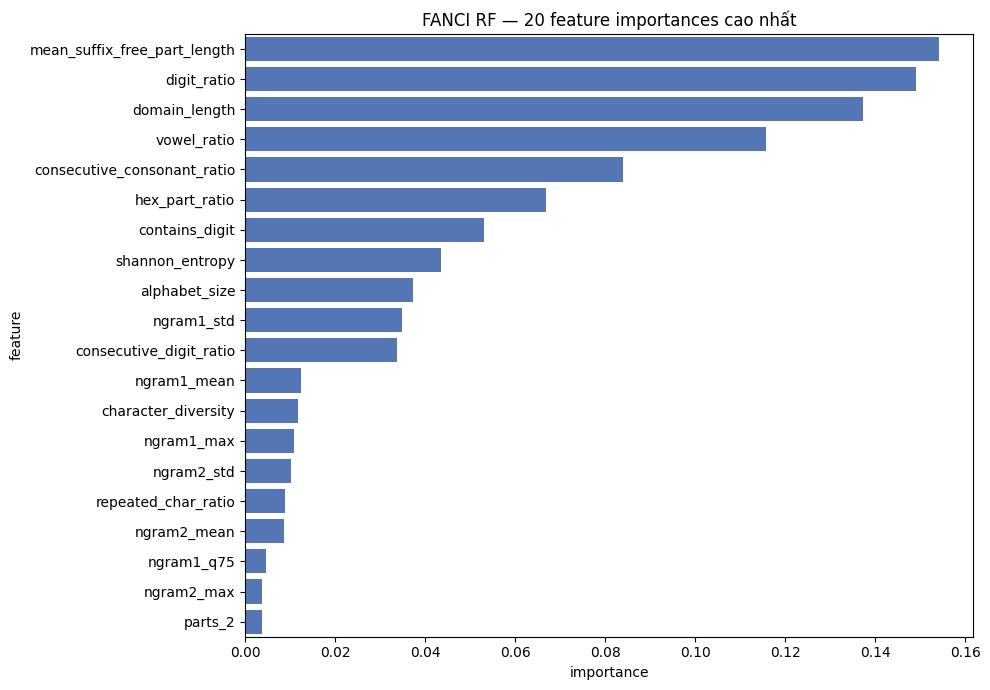

In [10]:
# Báo cáo recall theo từng họ DGA trên test và lưu prediction để kiểm toán.
test_predictions = test_df[["domain", "normalized_domain", "subclass", "label"]].copy()
test_predictions["probability"] = test_probability.astype(np.float32)
test_predictions["prediction_default_0_5"] = (test_probability >= 0.5).astype(np.int8)
test_predictions["prediction_deploy"] = (test_probability >= tuned_threshold).astype(np.int8)

malicious = test_predictions.loc[test_predictions["label"].eq(1)].copy()
family_report = (
    malicious.groupby("subclass", dropna=False)
    .agg(
        samples=("label", "size"),
        recall_default_0_5=("prediction_default_0_5", "mean"),
        recall_deploy=("prediction_deploy", "mean"),
        mean_probability=("probability", "mean"),
    )
    .sort_values(["recall_deploy", "samples"], ascending=[True, False])
    .reset_index()
)
display(family_report.head(30))

importance = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False, ignore_index=True)
display(importance.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance.head(20), x="importance", y="feature", color="#4472C4")
plt.title("FANCI RF — 20 feature importances cao nhất")
plt.tight_layout()
plt.show()


## Xuất artifact vận hành

Bundle lưu model, threshold, đúng snapshot Public Suffix List và metadata cần cho testbed. Joblib dùng gzip
để giảm kích thước forest; thao tác lưu có thể lâu. Testbed phải dùng cùng công thức 45 chiều và nên dùng
cùng phiên bản scikit-learn ghi trong bundle. Không cần scaler vì Random Forest không chuẩn hóa feature.


In [11]:
run_metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_repository": "https://github.com/fanci-dga-detection/fanci",
    "source_commit": SOURCE_COMMIT,
    "extractor_version": EXTRACTOR_VERSION,
    "feature_count": 45,
    "paper_code_dimension_note": (
        "Paper appendix says 44; official source and tests produce indices 0..44 (45 dimensions)."
    ),
    "psl_sha256": PSL_SHA256,
    "rf_config": RF_CONFIG,
    "training_seconds": training_seconds,
    "validation_inference_seconds": val_inference_seconds,
    "test_inference_seconds": test_inference_seconds,
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "sklearn_version": sklearn.__version__,
    "joblib_version": joblib.__version__,
    "cleaning": cleaning_report,
}

all_metrics = {
    "validation_default_0_5": val_default_metrics,
    "validation_tuned": val_tuned_metrics,
    "test_default_0_5": test_default_metrics,
    "test_tuned": test_tuned_metrics,
}

bundle = {
    "format_version": 1,
    "model_type": "fanci_random_forest_official45",
    "model": model,
    "best_threshold": float(tuned_threshold),
    "paper_threshold": 0.5,
    "feature_names": FEATURE_NAMES,
    "feature_count": 45,
    "extractor_version": EXTRACTOR_VERSION,
    "valid_tlds": sorted(VALID_TLDS),
    "valid_public_suffixes": sorted(VALID_PUBLIC_SUFFIXES),
    "psl_sha256": PSL_SHA256,
    "preprocessing": {
        "normalization": "strip + lowercase + remove trailing dot",
        "domain_scope": "full observed domain",
        "requires_scaler": False,
    },
    "rf_config": RF_CONFIG,
    "metrics": all_metrics,
    "metadata": run_metadata,
}

temporary_bundle = BUNDLE_PATH.with_suffix(BUNDLE_PATH.suffix + ".part")
if temporary_bundle.exists():
    temporary_bundle.unlink()
print("Đang nén và lưu model; bước này có thể kéo dài...")
joblib.dump(bundle, temporary_bundle, compress=("gzip", 3), protocol=5)
temporary_bundle.replace(BUNDLE_PATH)

metric_table.to_csv(REPORT_DIR / "metrics.csv", index=False)
importance.to_csv(REPORT_DIR / "feature_importance.csv", index=False)
family_report.to_csv(REPORT_DIR / "test_family_recall.csv", index=False)
test_predictions.to_csv(REPORT_DIR / "test_predictions.csv", index=False)
(REPORT_DIR / "metrics.json").write_text(
    json.dumps({"metrics": all_metrics, "metadata": run_metadata}, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Saved:", BUNDLE_PATH)
print("Artifact size GiB:", round(BUNDLE_PATH.stat().st_size / 2**30, 3))
print("Artifact SHA256:", sha256_file(BUNDLE_PATH))


Đang nén và lưu model; bước này có thể kéo dài...
Saved: /content/drive/MyDrive/FANCI_RF_genAI/artifact/fanci_rf_official45_bundle.joblib
Artifact size GiB: 0.992
Artifact SHA256: 952032ee5f1c0fec3190720adb1f34df0b522036de2a99f3d423b3a3d380bae5


In [2]:
# Reload từ disk và kiểm tra parity để phát hiện artifact hỏng hoặc thiếu metadata.
reloaded = joblib.load(BUNDLE_PATH)
assert reloaded["feature_count"] == 45
assert reloaded["feature_names"] == FEATURE_NAMES
assert reloaded["psl_sha256"] == PSL_SHA256
assert len(reloaded["model"].estimators_) == 785

sample_size = min(128, len(X_test))
before = model.predict_proba(X_test[:sample_size])[:, 1]
after = reloaded["model"].predict_proba(X_test[:sample_size])[:, 1]
np.testing.assert_allclose(after, before, rtol=0, atol=0)
print("PASS: artifact reload parity exact trên", sample_size, "mẫu.")


NameError: name 'joblib' is not defined

In [ ]:
# Ví dụ inference độc lập từ bundle vừa xuất.
def predict_domains(domains, loaded_bundle=reloaded):
    runtime_extractor = OfficialFANCI45Extractor(
        loaded_bundle["valid_tlds"], loaded_bundle["valid_public_suffixes"]
    )
    normalized = [str(domain).strip().lower().rstrip(".") for domain in domains]
    features = np.vstack([runtime_extractor.extract(domain) for domain in normalized])
    probabilities = loaded_bundle["model"].predict_proba(features)[:, 1]
    threshold = float(loaded_bundle["best_threshold"])
    return pd.DataFrame({
        "domain": domains,
        "normalized_domain": normalized,
        "probability_dga": probabilities,
        "prediction": (probabilities >= threshold).astype(np.int8),
        "threshold": threshold,
    })


display(predict_domains([
    "google.com",
    "itsec.rwth-aachen.de",
    "6301un092rsh.org",
]))


## File đầu ra

- `artifact/fanci_rf_official45_bundle.joblib`: model dùng cho testbed.
- `artifact/fanci_public_suffix_d6c7d08.txt`: snapshot PSL đã khóa hash.
- `reports/metrics.csv` và `metrics.json`: validation/test ở threshold 0.5 và threshold chọn từ validation.
- `reports/test_predictions.csv`: prediction từng domain test.
- `reports/test_family_recall.csv`: recall theo họ DGA.
- `reports/feature_importance.csv`: độ quan trọng của 45 chiều.
- `reports/cleaning_report.json`: số mẫu loại và hash dữ liệu.

Khi so sánh với hệ thống khác, dùng hàng `test / paper_default_0.5` nếu mục tiêu là baseline gần paper,
hoặc dùng `test / validation_f1` nếu toàn bộ baseline đều được phép chọn threshold trên validation. Không dùng
kết quả đã tune trực tiếp trên test.
